# Decoding PicoQuantFit Fluorescence TTTR Files (.ptu) and Fitting of Fluorescence Decays

This script deals with decoding of PicoQuant TTTR files (.ptu) produced by HydraHarp V2 and fitting of the fluorescence decays in each image pixel. First, the header section is decoded to gain necessary information for proper decoding of the photon record data and the actual microscope image, i.e. the position in x and y where a particular photon record was made. Second, the photon recond data are read and sorted into a 3D array. This array holds the fluorescence decay curves of each pixel and are subsequently fitted to obtain fluorescence lifetimes.

**In this script, only HydraHarp V2 TTTR data are treated and decoded. However, it can easily be expanded to also cover different PicoQuant TCSPC hardware.**

This script is based on PicoQuants' .ptu decoding example (https://github.com/PicoQuant/PicoQuant-Time-Tagged-File-Format-Demos/blob/master/PTU/Python/Read_PTU.py) and an adaption of that script for the PhasorFLIM application written in JavaScript (https://github.com/Tomkaehst/PhasorFLIM/blob/master/app/filedecoding/PTUReaderBitwise.js).

Furthermore, this Jupyter Notebook serves as interactive sandbox environment and the actual data processing should be done in dedicated Python scripts. 


## PTU File Architecture

*.ptu* files consist of a header and record section. In the header, information about the FLIM system and imaging parameters are stored, which are required in order to reconstruct FLIM images from the single photon data encoded in the record section.
In the following section, the header information is read and stored in a tuple for easier access down the road.

### File Magic

*.ptu* files can be identified and verified by the file magic string encoded in the first eight bytes. It should read ```PQTTTR```. The next eight bytes contain the file version (see ).

After file verification, header tags of different data types are read out. The header end is indicated by "Header_End" and can be searched for to know when to stop decoding it. Header data types are indicated by type code tags in each 48 byte header data piece. It is checked to decide what data type should be extracted from the binary file. To read the photon record data from the following file section, the record type has to be known. This is also encoded in the header section.

In [95]:
# Loading requires Python modules for the *whole* script!
import sys, struct, io, os
import math
import numpy as np
from numba import jit
from scipy.optimize import curve_fit
from scipy import optimize
import scipy.stats as stats
from scipy.integrate import odeint
%matplotlib inline 
import matplotlib.pyplot as plt


# Filepath for test files and creation of a filestream using read-binary
ptupath = 'qt_app/testData/20190418_EGFP.sptw/Cherry-EGFP-Fusion_1/Cherry-EGFP-Fusion_1_1.ptu'
ptureadstream = open(ptupath, 'rb')

# Reading file magic to check if file is PTU file, first 8 byte
filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

# Checking file valiidy by reading file magic and file version
if(filemagic != 'PQTTTR'):
    print('%s is not a .ptu file!' % ptupath)
    ptureadstream.close()
else:
    print('%s is a valid .ptu file... Commencing.' % ptupath)

    
fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
print('File Version: %s' % fileversion)

qt_app/testData/20190418_EGFP.sptw/Cherry-EGFP-Fusion_1/Cherry-EGFP-Fusion_1_1.ptu is a valid .ptu file... Commencing.
File Version: 1.0.00


In [96]:
# Adjusting figure size of subsequent plots using matplotlib.plt
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 10
fig_size[1] = 8
plt.rcParams["figure.figsize"] = fig_size

print(sys.version,"\n" ,sys.path)

3.7.5rc1 (default, Oct  8 2019, 16:47:45) 
[GCC 9.2.1 20191008] 
 ['/home/agbp/Documents/PhasorFLIM', '/usr/lib/python37.zip', '/usr/lib/python3.7', '/usr/lib/python3.7/lib-dynload', '', '/home/agbp/.local/lib/python3.7/site-packages', '/usr/local/lib/python3.7/dist-packages', '/usr/lib/python3/dist-packages', '/home/agbp/.local/lib/python3.7/site-packages/IPython/extensions', '/home/agbp/.ipython']


### PTU File Header & Record Tag Type Definitions

In [97]:
# Definition of header tag types
'''
Each header piece begins with a tag type. It is checked and depending on the type,
different data types have to be extracted.
'''

tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

# Defining record types
'''
Record types of different PicoQuant TCSPC devices. Different TCSPC devices,
require different modes of photon record retrieval. See PicoQuant
documentary for further information. 
Here, only rtHydraHarp2T3 data are considered.
'''
rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]

## Decoding Header Information
In the first file segment, information about the measurement are encoded in different data types (see PicoQuant TTTR documententation in GitHub repository above).
Each header piece has 48 bytes. 

- 0:32 holds the tag ID (e.g. filename, image dimensions, ...)
- 32:36 holds the tag index
- 36:40 holds tag data type identifier (see above)
- 40:48 holds actual tag value

The header is read in 48 byte chunks until the header end tag is encounterd. The detected tag data type decides how a header piece is treated. If a string is identified, the tag value variable indicates in how many bytes the string in encoded. After treatment, header chunks are stored in the header_contents dictionary.

In [98]:
## setting up header end string to terminate header decoding in while loop 
headerend_tag = 'Header_End'
reached_headerend = False


# tuple that stores decoded information from header section
header_contents = {}

# decoding header
while(reached_headerend == False):
    headerpiece = ptureadstream.read(48)
    tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
    tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
    tagType = struct.unpack('<i', headerpiece[36:40])[0]
    tagVal = headerpiece[40:48]
    
    if(tagId == headerend_tag):
        reached_headerend = True
        ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
        print('Found Header_End.')
        break
    
    if(tagType == tyEmpty8):
        header_contents['Empty'] =  'Empty'
        
    elif(tagType == tyBool8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyInt8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8):
        value = struct.unpack('<d', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8Array):
        value = struct.unpack("<q", tagVal)[0]
        print('Float array with %d entries' % value / 8)
        
    elif(tagType == tyAnsiString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('latin1').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyWideString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyBinaryBlob):
        value = struct.unpack("<q", tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyBitSet64):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyColor8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  "{0:#0{1}x}".format(value,18)
        
    elif(tagType == tyBinaryBlob):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value

    elif(tagType == tyTDateTime):
        print(' ')
        
    else:
        continue
        #print('Unknown header tag type. Ignored.')
        
    
headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header
    
print('Finished decoding header.')

 
Found Header_End.
Finished decoding header.


The releveant header information is now copied into a new structure for convinient access.
In order to reconstruct the FLIM image, several value are required

- Filename: Filename
- Comment: String containing user comments
- TTResultsFormat_TTTRRecType: Type of the photon records i.e. which device was used
- TTResultFormat_BitsPerRecord: Number of bits in a photon record
- ReqHdr_SpatialResolution: Width of a pixel in µm
- ImgHdr_PixX: How many pixels in X?
- ImgHdr_PixY: How many pixels in Y?
- MeasDesc_GlobalResolution: time resolution of measurement
- HW_BaseResolution: Principal time resolution of device
- MeasDesc_Resolution: TCSPC resolution, also obtained by BaseResolution * BinningFactor
- MeasDesc_BinningFactor: Binning factor
- TTResult_SyncRate: Laser pulse / Sync rate of measurement
- TTResult_NumberOfRecords: How many 32 bit records in file?

In [99]:
FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'Comment': header_contents['$Comment'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
}
FLIMInfo

{'Filename': 'Cherry-EGFP-Fusion_1_1',
 'Comment': 'LAS X 2.0.1.14392\npCherry-EGFP transfected U2OS, 48 h post trans, ex at 488 with 20 MHz WLL (Notch filter), det from 500 to 550 and 605 to 660 (for Cherry)\nPinhole: 58.69 µm\nObjective: HC FLUOTAR L 25.0 WATER\nImage Format: 1024 x 1024\nScan Speed: 100 Hz\nZoom: 2.0\nFrame Average: 50\nDirection: Unidirectional\n\nWLL\n LaserLine 488: 0.7\n Laser Shutter: Open\n\nLaser (WLL, WLL) On 70.0\nLaser (Argon, visible) Off 0.0\nLaser (IR, MP) On\nLaser (IR2, FSOPO) On\nMFP Filter: Substrate \nPolarization Filter: NF 488\nNotch Filter: Empty\nX1-Port: Mirror \nScan Mode: xyz\nZPosition: -0.60 µm\nSpectral detection range\nSP PMT 1: 500...550nm \nSP PMT 2: 605...660nm \n\nFLIM Detector: Intern\nAcquisition Mode: Frame Repetition 50\n',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 2.1623884549626382e-07,
 'PixelsX': 1024,
 'PixelsY': 1024,
 'GlobalResolution': 5.141419895649742e-08,
 'BaseResolution': 9.999999960041972e-

## Decoding Photon Records
After header reading, we have sufficient information to decode the photon data from the ```.ptu``` file. **Because in this script, only HydraHarp V2 TTTR data are decoded**, only this record type is considered.

### Photon Data Architecture
A HydraHarp V2 TTTR record has 32 bits and encodes three types of information:
- marker
    - Indicates channel in which photon was detected, of regular photon record occured
    - Indicates several special records
        - macro time overflow
        - frame and line start or stop
- macro time
    - Experiment time in s
- nano time
    - time of photon arrival realtive to laser pulse


#### Meaning of Marker Events

The marker stream consists of two elements: the special bit and the channel bits. The special bit is the first bit of each 32 bit photon record. When it is set it indicates that the record is not a photon, but a system marker event: line start (65 = 1000001), line stop (67 = 1000010), or an macrotime clock overflow (127 = 1111111) [frame start and stop are not encoded in our setup].
When the special bit is not set, the channel bits indicate the channel number in which the photon event was registered.
In the case of an macrotime bit overflow, the nanotime bits encode the number of times an overflow has occured so far (comment to self: check this again in the documentary). This is required to calculate the real macrotime of the experiment.

In [100]:
ptureadstream.close()

### Rewriting *.ptu* Decoding with NumPy 
Only photon record section for now. Byte offset until photon records saved above after ```Header_End``` tag has been detected.

In [101]:
@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)

In [102]:
## Trying to use NumPy for binary decoding and processing

## Data type definition for recordarray
### Data types are chosen, so that they use the least space possible
recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                              ('nanotime', np.float64), ('macrotime', np.float64)])


# Preallocating array with decoded raw FLIM data
recordarray = np.zeros(
        shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

# Factors required to recover real macro and nanotimes from raw photon data stream
macroMultFactor = FLIMInfo['GlobalResolution']
nanoMultFactor = FLIMInfo['Resolution'] * 1e9


# Opening .ptu file and shoveling it into UInt32 section of preallocated array
with open(ptupath, 'rb') as file:
    file.seek(headerend_bitoffset)
    recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
    file.close()
    
# Recover marker signals and nanotimes of photon events
recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor


# Recover macrotimes and treat overflows
recordarray = treatOverflows(recordarray, macroMultFactor)

In [103]:
# Checking if macrotime has been properly corrected. If so, it increases over number of events.
#plt.plot(recordarray['macrotime'])
#plt.show()

In [104]:
#plt.hist(recordarray['nanotime'], bins=500, range = (1, 50), log = "y")
#plt.title("Histogram: All nanotimes, all channels")
#plt.show()

## Reconstructing Image from Data Stream

In [105]:
@jit(nopython=True)
def countLines(recordarray):
    '''
    Function: countLines(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    )
    
    - Counts number of line start (marker == 65) and line stop (marker == 66) events in raw photon data
    - Purpose: check data integrity
    '''

    numLinesStart = np.sum(recordarray['marker'] == 65)
    numLinesStop = np.sum(recordarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart

In [106]:
@jit(nopython=True, cache=True)
def checkChannelAvailability(recordarray):

    channelList = []

    if(np.any(recordarray['marker'] == 0)):
        channelList.append(0)

    if(np.any(recordarray['marker'] == 1)):
        channelList.append(1)

    if(np.any(recordarray['marker'] == 2)):
        channelList.append(2)

    if(np.any(recordarray['marker'] == 3)):
        channelList.append(3)

    print("Detected channels: ", channelList)

    return channelList

In [107]:
FLIMInfo['channelList'] = checkChannelAvailability(recordarray)

Detected channels:  [0, 1]


In [108]:
FLIMInfo['LinesInFile'] = countLines(recordarray)

In [109]:
FLIMInfo

{'Filename': 'Cherry-EGFP-Fusion_1_1',
 'Comment': 'LAS X 2.0.1.14392\npCherry-EGFP transfected U2OS, 48 h post trans, ex at 488 with 20 MHz WLL (Notch filter), det from 500 to 550 and 605 to 660 (for Cherry)\nPinhole: 58.69 µm\nObjective: HC FLUOTAR L 25.0 WATER\nImage Format: 1024 x 1024\nScan Speed: 100 Hz\nZoom: 2.0\nFrame Average: 50\nDirection: Unidirectional\n\nWLL\n LaserLine 488: 0.7\n Laser Shutter: Open\n\nLaser (WLL, WLL) On 70.0\nLaser (Argon, visible) Off 0.0\nLaser (IR, MP) On\nLaser (IR2, FSOPO) On\nMFP Filter: Substrate \nPolarization Filter: NF 488\nNotch Filter: Empty\nX1-Port: Mirror \nScan Mode: xyz\nZPosition: -0.60 µm\nSpectral detection range\nSP PMT 1: 500...550nm \nSP PMT 2: 605...660nm \n\nFLIM Detector: Intern\nAcquisition Mode: Frame Repetition 50\n',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 2.1623884549626382e-07,
 'PixelsX': 1024,
 'PixelsY': 1024,
 'GlobalResolution': 5.141419895649742e-08,
 'BaseResolution': 9.999999960041972e-

In [110]:
@jit(nopython=True, cache=True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in nss

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position
    # Count out-of-range photons (photons with macrotime below or above line time difference)
    oorPhotons = 0

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray['marker'][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray['macrotime'][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        if(tmpMarker == 0 or tmpMarker == 1 or tmpMarker == 2 or tmpMarker == 3):
            oorPhotons += 1

        while(lineActive == True):
            tmpMarker = recordarray['marker'][eventCounter]
            tmpMacro = recordarray['macrotime'][eventCounter]
            tmpNanotime = recordarray['nanotime'][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins)

                    if(pixelIDY < 0 or pixelIDY > nPixelY):
                        oorPhotons = oorPhotons + 1
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1

    print("Assigned photons to pixels.\n",
          (oorPhotons / np.sum(intensityImage))*100,
          "% of photons were out of range... Total:", oorPhotons, "of", np.sum(intensityImage), "photons.")

    return flimarray, intensityImage


In [111]:
flimarray, intimage = buildFLIMArray(recordarray,
                                     0,
                                     FLIMInfo['LinesInFile'],
                                     FLIMInfo['PixelsX'],
                                     FLIMInfo['PixelsY'],
                                     FLIMInfo['GlobalResolution'],
                                     FLIMInfo['Resolution'],
                                     4,
                                     4)
recordarray = None # dereferencing recordarray for garbage collection; in the future: ptu processing via data stream!

Assigned photons to pixels.
 5.335754249993352 % of photons were out of range... Total: 142468 of 2670063 photons.


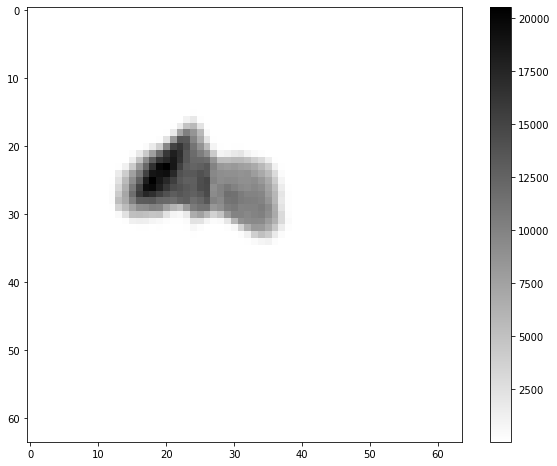

In [116]:
plt.imshow(intimage, cmap = "gray_r")
plt.colorbar()
plt.show()

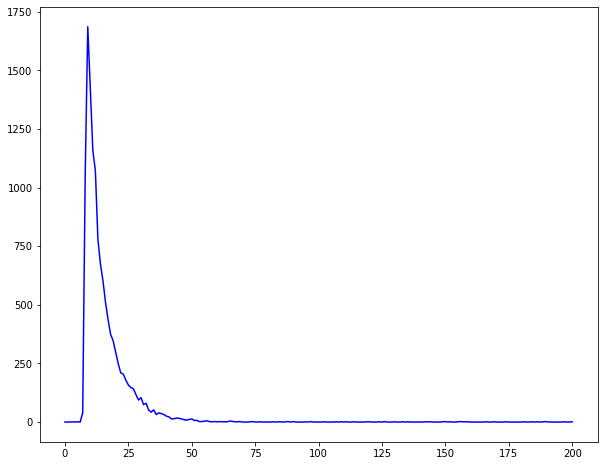

In [121]:
plt.plot(flimarray[25][23][:], 'b-')
#plt.yscale("log")
plt.show()

## Data Fitting
The functions above produced two arrays, one holding the intensity image (2D, intImg) and one holding the fluorescence decays (3D, flimarray).

As a first attempt, the fluorescence lifetimes of the image are determined by tail fitting. Iterative reconvolution and model-based fitting is implemented bases upon that.

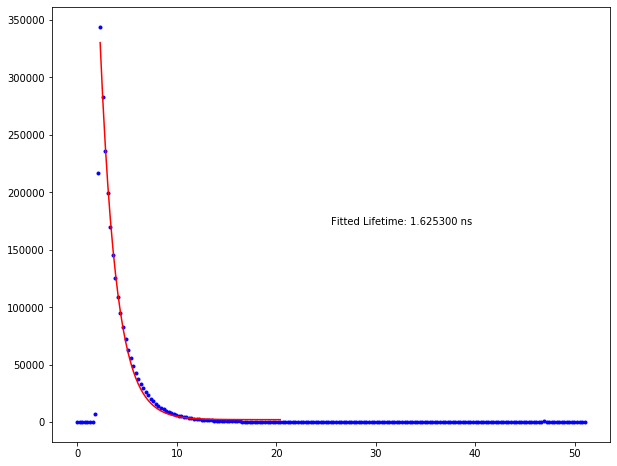

1.6253

In [123]:
# Simple exponential decay


def expDecay(x, a, b, tau):
    return(a * np.exp(-x/tau) + b)

def globalTailFit(flimarray, FLIMInfo, showPlot = True):
      # There's definitely a smarter way to do this.
    overallDecay = np.sum(np.sum(flimarray, axis=0), axis=0)
    #overallDecay = np.sum(np.where())
    xaxis = np.linspace(
        0, round(FLIMInfo['GlobalResolution']*10E8), flimarray.shape[2])
    maxVal = np.where(overallDecay == max(overallDecay))[0][0]
    endOfData = overallDecay.size - 100
    plt.plot(xaxis, overallDecay, 'b.')
    tau_fit, tau_cov = curve_fit(
        expDecay, xaxis[maxVal:endOfData-20], overallDecay[maxVal:endOfData-20], p0=(max(overallDecay), 0, 5))

    lifetime = round(tau_fit[2], 4)

    if(showPlot == True):
        plt.text(1/2*max(xaxis), max(overallDecay)/2, "Fitted Lifetime: %f ns" % lifetime)
        plt.plot(xaxis[maxVal:endOfData-20],
             expDecay(xaxis, *tau_fit)[maxVal:endOfData-20], 'r-')

        plt.show()

    return(lifetime)

globalTailFit(flimarray, FLIMInfo, showPlot = True)

### Pixel-wise Fitting (Paralellized with Numba)




[1997.57047659 2492.93030495   30.42996713]
[[ 2.97437896e+01 -3.67597365e+01 -6.18222106e-02]
 [-3.67597365e+01  1.10688890e+02 -2.47071286e+00]
 [-6.18222106e-02 -2.47071286e+00  5.10552693e-01]]

SciPy ChiSq:	 1107.5501661399212 	p value: 5.351034264196562e-89
chisq =		 1107.5501661399212   3.5272298284710866 
df =		 316


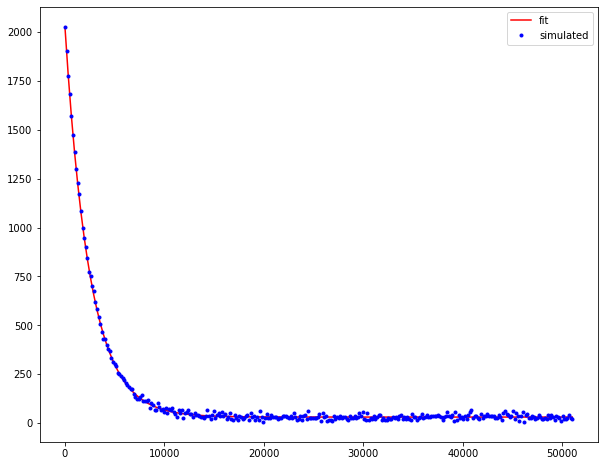

In [159]:
def expDecay_lm(t, N0, tau, offset):
    y = N0 * np.exp(-t/tau) + offset
    return(y)


T = 51000
dt = 160
N0 = 2000
tau = 2500
offset = 10
stdev = 5

# Create the artificial dataset
t = np.linspace(0, T, T/dt)
N = expDecay_lm(t, N0, tau, stdev)
Nfluct = stdev * np.random.poisson(stdev, size = len(t))
N += Nfluct
sig = np.zeros(len(t)) + stdev

# Fit the curve
start = (20000, 2400, 0)
#popt, pcov = curve_fit(expDecay_lm, t, N, sigma = sig, p0 = start, absolute_sigma=True, method = 'lm')
popt, pcov = curve_fit(expDecay_lm, t, N, p0 = start, method = 'lm')
print(popt)
print(pcov)

# Compute chi square
Nexp = expDecay_lm(t, *popt)
chisq = np.sum(((N - Nexp)**2)/Nexp)#np.sum(((N - Nexp))/Nexp)**2
chisq_scipy = stats.chisquare(N, Nexp, 3)

chisq_red = chisq/(len(N) - 4)
df = len(t) - 2

print('\nSciPy ChiSq:\t', chisq_scipy[0], "\tp value:", chisq_scipy[1])
print('chisq =\t\t',chisq, " ", chisq_red,'\ndf =\t\t', df)
# Plot the data with error bars along with the fit result
#plt.errorbar(t, N, yerr=sig, fmt = 'o', label='"data"')
plt.plot(t, Nexp, 'r-', label = 'fit')
plt.plot(t, N, 'b.', label = 'simulated')
#plt.yscale('log')
plt.legend()
plt.show()

In [126]:
from numba import prange, njit # njit is short-hand for @jit(nopython=True)


def expDecay(x, a, b, tau):
    return(a * np.exp(-x/tau) + b)

#@jit(nopython = False, parallel = True)
def pixelwiseSimpleDecay(flimarray, photonthreshold, rightcutoff, globRes):
    '''
        Function: pixelwiseSimpleDecay(
            - flimarray: 3D array x-y-ns holding fluorescence decays for each image pixel
            - photonthreshold: number of photons in pixel required to start fitting
            - rightcuttoff: how much data of decay to exclude from the right side of the curve
            - globRes: FLIMInfo['GlobalResolution'], required to reconstruct time axis with correct time (in ns)
        )
    '''
    numDecaysX = flimarray.shape[0]
    numDecaysY = flimarray.shape[1]
    
    lifetimeImage = np.zeros((numDecaysX, numDecaysY), dtype = np.float64)
    tau_fit = []
    tau_cov = []
    
    for x in prange(numDecaysX):
        for y in range(numDecaysY):
            if(flimarray[x][y][:].sum() > photonthreshold):
                xaxis = np.linspace(0, round(globRes*10E8), flimarray.shape[2])
                maxVal = np.where(flimarray[x][y] == max(flimarray[x][y]))[0][0]
                endOfData = flimarray[x][y].size - rightcutoff
                try:
                    tau_fit = curve_fit(expDecay, xaxis[maxVal:endOfData], flimarray[x][y][maxVal:endOfData])[0]
                    lifetimeImage[x][y] = tau_fit[2]
                except:
                    lifetimeImage[x][y] = 100
            else:
                lifetimeImage[x][y] = 100
        
    
    return(lifetimeImage)

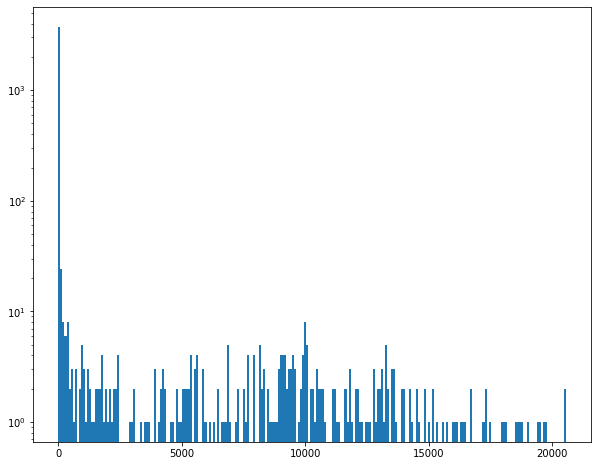

In [127]:
# Show histogram of pixel-photon count
photonDistribution = plt.hist(np.reshape(intimage, (intimage.size)), bins = 250, log = True)
plt.show()

In [128]:
fittedImage = pixelwiseSimpleDecay(flimarray, 100, 10, FLIMInfo['GlobalResolution'])

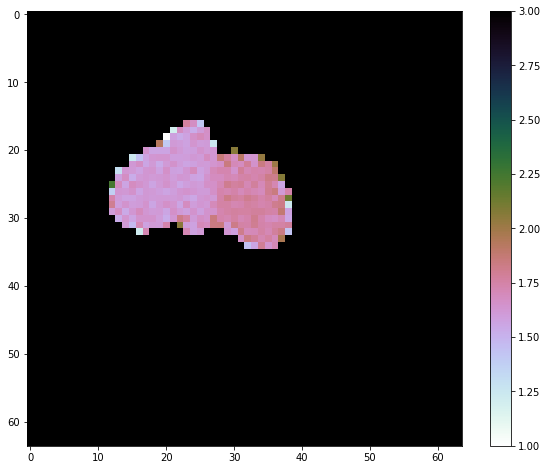

In [130]:
plt.imshow(fittedImage, cmap = "cubehelix_r")
plt.clim(1, 3)
plt.colorbar()
plt.show()

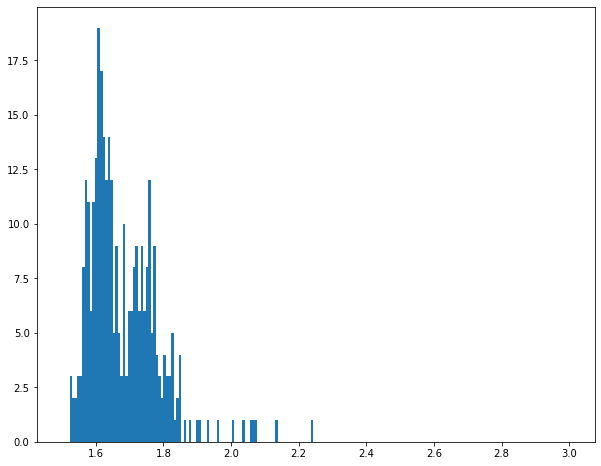

In [131]:
fittedHist = plt.hist(np.reshape(fittedImage, (fittedImage.size)), range = (1.5, 3), bins = 200, density = False)
plt.show()

## Reconvolutional Fitting

Monoexponential decay:


$$N(t) = N_0 e^{-t/\tau}$$

[7.92275693e+01 8.53467398e-01 2.50338961e+03 1.28943407e+00
 2.00121693e+03 9.76254497e+01]
	Input Parameters	 Fitted Parameters
---------------------------------------------
N0 	 100 			 79.227569332246
offset 	 0 			 0.8534673976547161
tau 	 2500 			 2503.3896085993356
amp 	 1 			 1.2894340693788053
dplace 	 2000 			 2001.2169330580684
grsm 	 100 			 97.6254496981008


Chi-Sq (abs. / red.):	 269.19019564034465 	 0.8627890885908482
Chi-Sq (SciPy):		 269.19019564034465 	 0.8627890885908482  (p-value: 0.9582742952411217 



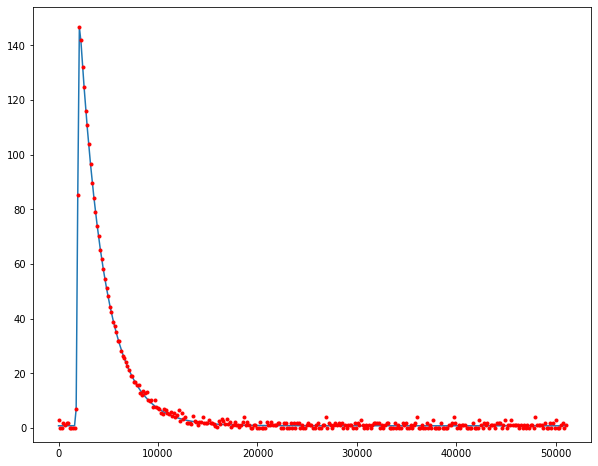

In [161]:
def gauss_laser(t, amp, dplace, grsm):
    y = amp * np.exp(-(t - dplace)**2 / (2 * grsm**2))
    return(y)

def expDecay(t, N0, yoffset, tau):
    return(N0 * np.exp(-t/tau))

def convolutedDecay(t, N0, yoffset, tau, amp, dplace, grsm):
    laser = gauss_laser(time, amp, dplace, grsm)
    decay = expDecay(time, N0, yoffset, tau)
    
    convolvedSignal = np.convolve(decay, laser, mode = 'full')[0:n]
    convolvedSignal += yoffset
    
    return(convolvedSignal)

# Objective function
def residuals(para_est):
    return(ydata - convolutedDecay(time, *para_est))


T = 51000
dt = 160
n = int(T/dt)
noise = 1
time = np.linspace(0, T, n)
xdata = time

# Simulation parameters
para_sim = (100, 0, 2500, 1, 2000, 100) # N0, yoffset, tau, amp, dplace, grsm
para_names = ("N0", "offset", "tau", "amp", "dplace", "grsm")

# Simulating data and adding Poisson noise
simulated = convolutedDecay(time, *para_sim)
ydata = simulated + np.random.poisson(noise, len(simulated))

# Initial guessing and Data Fitting
para_start = (80, 0, 2000, 2, 1800, 200)

#para_opt, para_cov = optimize.leastsq(residuals, para_start)
para_opt = optimize.least_squares(residuals,
                                  para_start,
                                  loss = 'cauchy',
                                  method = 'trf')

print(para_opt['x'])

fitted_curve = convolutedDecay(time, *para_opt['x'])

plt.ylim(-5, max(ydata) + max(ydata)/100*5)
plt.plot(time, fitted_curve)
plt.plot(time, ydata, 'r.')
#plt.yscale('log')

print("\tInput Parameters\t Fitted Parameters")
print("---------------------------------------------")
for i in range(0, len(para_opt['x'])):
    print(para_names[i],"\t", para_sim[i], "\t\t\t", para_opt['x'][i])
    
    
    
# Chi-Squared
chisq = np.sum(((ydata - fitted_curve)**2)/fitted_curve)
chisq_scipy = stats.chisquare(ydata, fitted_curve, len(para_start))

chisq_red = chisq/(len(ydata) - len(para_start))
df = len(ydata) - len(para_start)

print("\n")
print("Chi-Sq (abs. / red.):\t", chisq, "\t", chisq_red)
print("Chi-Sq (SciPy):\t\t", chisq_scipy[0], "\t", chisq_scipy[0]/df, " (p-value:", chisq_scipy[1], "\n")

## Fitting with ODEs

[2.58893455]


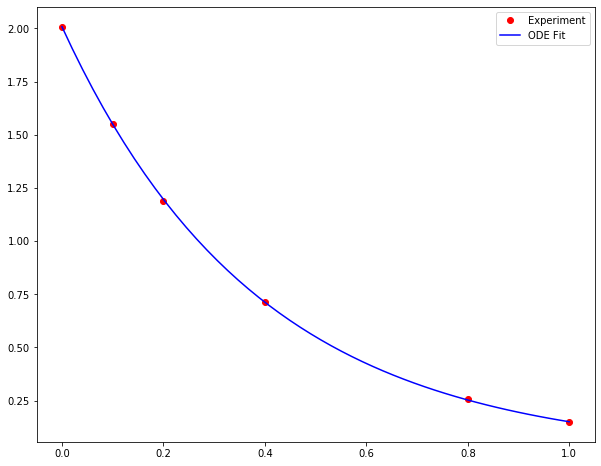

In [134]:
# ODE Fitting in NumPy/SciPy
t = [0, 0.1, 0.2, 0.4, 0.8, 1]
Ca_data = [2.0081, 1.5512, 1.1903, 0.7160, 0.2562, 0.1495]

def fitfunc(t, k):
    def myode(Ca, t):
        return -k * Ca
    
    Ca0 = Ca_data[0]
    Casol = odeint(myode, Ca0, t)
    return Casol[:, 0]

k_fit, k_cov = curve_fit(fitfunc, t, Ca_data, p0 = 1.3)
print(k_fit)

tfit = np.linspace(0, 1);
fit = fitfunc(tfit, k_fit)

plt.plot(t, Ca_data, 'ro', label = "Experiment")
plt.plot(tfit, fit, 'b-', label = "ODE Fit")
plt.legend(loc = "best")
plt.show()

In [135]:
def gauss_laser(t, amp, dplace, grsm):
    y = amp * np.exp(-(t - dplace)**2 / (2 * grsm**2))
    return(y)

def mono_decay(t):#, tau, laserAmp, laserDplace, laserGRSM):
    D0 = 100000
    D1 = 0
    time = t
    f = 1/2.5
    
    laser = gauss_laser(time, 1, 10, 2.5)
    
    dD1 = -f * D1 + laser
    dD0 = -dD1
    
    return(dD0, dD1)

In [136]:
t_test = np.linspace(0.0, 100.0, 1000)
laser_test = gauss_laser(t_test, 1, 10, 2.5)

In [137]:
test_int = odeint(mono_decay, [0], t_test)

TypeError: mono_decay() takes 1 positional argument but 2 were given